# Notebook 00 — Custom Dataset: Cleaning, EDA & Reproducible Splits


In [1]:
import re
import unicodedata
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DATA_DIR = Path("../data/pharmacy_lk")          # adjust if your layout differs
IMG_DIR = DATA_DIR / "images"
OUT_DIR = DATA_DIR / "splits"
FIG_DIR = Path("../reports/figures")
for d in (OUT_DIR, FIG_DIR):
    d.mkdir(parents=True, exist_ok=True)

SEED = 42
rng = np.random.default_rng(SEED)

# ---------------- Cleaning policy (every switch = one methodology sentence) ----------
LOWERCASE = True          # 'Nexe' vs 'nexe' are the same drug; case is not discriminative
MIN_LABEL_LEN = 2         # 1-char labels are almost certainly annotation fragments

# Dosage-form / route words. Two distinct uses:
#  (1) If a label is ONLY a form word (e.g. "tablet") -> drop the row (not a medicine name).
#  (2) If a form word appears alongside a name (e.g. "tab. augmentin 625mg") -> strip just
#      the form word, KEEP name + dose -> "augmentin 625mg".
# Conservative allow-list ONLY. Deliberately EXCLUDES 'mups' and 'plus', which are parts of
# real brand names (Nexum Mups, Acliz Plus); stripping them would corrupt medicine names.
FORM_TOKENS = {
    "tablet", "tab", "capsule", "cap", "injection", "inj", "syrup", "syp",
    "suspension", "susp", "ointment", "oint", "cream", "gel", "drops", "drop",
    "solution", "soln", "sol", "sachet", "spray", "diet",
}
STRIP_FORM_TOKENS = True    # keep name + dose, remove form/route words only
FILTER_NON_MEDICINE = True  # drop rows that are ONLY a form word after stripping

# Cyrillic -> Latin homoglyph map (covers the contamination found in the audit;
# extend if the verification cell reports remaining non-Latin characters)
HOMOGLYPHS = str.maketrans({
    "А": "A", "В": "B", "С": "C", "Е": "E", "Н": "H", "К": "K", "М": "M",
    "О": "O", "Р": "P", "Т": "T", "Х": "X",
    "а": "a", "в": "b", "с": "c", "е": "e", "к": "k", "м": "m",
    "о": "o", "р": "p", "т": "t", "х": "x", "у": "y", "и": "u", "п": "n",
})

## 1. Load and audit the raw annotations
The audit runs **before** cleaning so the thesis can report the raw state of the data —
annotation noise is a finding about real-world prescription data, not an embarrassment.

In [2]:
raw = pd.read_csv(DATA_DIR / "labels.csv")
raw["medicine_name"] = raw["medicine_name"].astype(str)
print(f"rows={len(raw)}  unique medicine names={raw.medicine_name.nunique()}")

charset = sorted(set("".join(raw.medicine_name)))
non_ascii = [c for c in charset if ord(c) > 127]
print("raw charset:", "".join(charset))
print("non-ASCII characters found:", non_ascii or "none")

missing_imgs = [f for f in raw.image_filename if not (IMG_DIR / f).exists()]
print(f"annotation rows whose image file is missing: {len(missing_imgs)}")

rows=5735  unique medicine names=1889
raw charset:  %()-./0123456789ABCDEFGHIJKLMNOPQRSTUVWXYZabcdefghijklmnopqrstuvwxyzТаморх
non-ASCII characters found: ['Т', 'а', 'м', 'о', 'р', 'х']
annotation rows whose image file is missing: 0


## 2. Cleaning pipeline
Order matters: unicode-normalise → homoglyph map → whitespace collapse → case policy →
filters. A per-row log records every row that was *changed* or *dropped*, with the reason
— this log is your audit trail for the viva.

In [3]:
def clean_text(s: str) -> str:
    """Normalise unicode, fix homoglyphs, collapse whitespace, apply case policy,
    and (if enabled) strip dosage-FORM words while preserving name + dose."""
    s = unicodedata.normalize("NFKC", s)
    s = s.translate(HOMOGLYPHS)
    s = re.sub(r"\s+", " ", s).strip()
    if LOWERCASE:
        s = s.lower()
    if STRIP_FORM_TOKENS:
        # Remove form words as whole tokens (allowing a trailing dot, e.g. 'tab.'),
        # but never touch name parts, dose numbers, units, 'mups'/'plus', etc.
        parts = [p for p in s.split(" ") if p.strip(".") not in FORM_TOKENS]
        s = re.sub(r"\s+", " ", " ".join(parts)).strip(" .-")
    return s


# --- Structured {name, strength, unit} parse (secondary-novelty support) ----------
# Guard rules learned from the data audit:
#   * require whitespace before the number (so 'k2cal'/'b12' are NOT split)
#   * only recognise a known unit vocabulary
#   * strength+unit are taken from the trailing dose, name is the remainder
DOSE_RE = re.compile(r"(?<=\s)(\d+\.?\d*)\s*(mg|mcg|ml|g|gm|iu|%|cal)\b")

def parse_structure(s: str) -> tuple[str, str, str]:
    m = DOSE_RE.search(s)
    if not m:
        return s, "", ""           # name-only label
    strength, unit = m.group(1), m.group(2)
    name = (s[:m.start()] + s[m.end():]).strip(" .-")
    name = re.sub(r"\s+", " ", name)
    return name, strength, unit


df = raw.copy()
df["medicine_name_raw"] = df["medicine_name"]
df["medicine_name"] = df["medicine_name"].map(clean_text)

log_rows = []
changed = df["medicine_name"] != df["medicine_name_raw"]
for _, r in df[changed].iterrows():
    log_rows.append({"image_filename": r.image_filename, "action": "modified",
                     "from": r.medicine_name_raw, "to": r.medicine_name})

# Drops, with reasons
drop_mask = pd.Series(False, index=df.index)

# Rows that became EMPTY after stripping were pure form words (e.g. 'tablet') -> drop
if FILTER_NON_MEDICINE:
    m = df.medicine_name.str.len() == 0
    for _, r in df[m].iterrows():
        log_rows.append({"image_filename": r.image_filename, "action": "dropped",
                         "from": r.medicine_name_raw, "to": "", "reason": "form-word only"})
    drop_mask |= m

m = (df.medicine_name.str.len() < MIN_LABEL_LEN) & ~drop_mask
for _, r in df[m].iterrows():
    log_rows.append({"image_filename": r.image_filename, "action": "dropped",
                     "from": r.medicine_name_raw, "to": "", "reason": "too short"})
drop_mask |= m

# Labels that STILL contain non-Latin chars after homoglyph mapping are unrecoverable noise
m = df.medicine_name.str.contains(r"[^\x00-\x7f]") & ~drop_mask
for _, r in df[m].iterrows():
    log_rows.append({"image_filename": r.image_filename, "action": "dropped",
                     "from": r.medicine_name_raw, "to": "", "reason": "non-latin residue"})
drop_mask |= m

clean = df[~drop_mask].drop(columns=["medicine_name_raw"]).reset_index(drop=True)

# Add structured columns (name / strength / unit) for M3 + field-level evaluation
parsed = clean.medicine_name.map(parse_structure)
clean["name"] = [p[0] for p in parsed]
clean["strength"] = [p[1] for p in parsed]
clean["unit"] = [p[2] for p in parsed]

pd.DataFrame(log_rows).to_csv(OUT_DIR / "cleaning_log.csv", index=False)

n_dose = (clean.strength != "").sum()
print(f"modified: {int(changed.sum())} rows | dropped: {int(drop_mask.sum())} rows | "
      f"remaining: {len(clean)} rows, {clean.medicine_name.nunique()} unique labels")
print(f"labels carrying a parsed dosage: {n_dose}  (secondary-novelty subset)")
print("post-clean charset:", "".join(sorted(set("".join(clean.medicine_name)))))

modified: 4237 rows | dropped: 459 rows | remaining: 5276 rows, 1612 unique labels
labels carrying a parsed dosage: 202  (secondary-novelty subset)
post-clean charset:  %()-./0123456789abcdefghijklmnopqrstuvwxyz


## 3. EDA figures for the Data chapter
Three figures: label-length distribution, label-frequency distribution (the long tail
is the key property motivating the seen/unseen-vocabulary analysis), and the top-30
most frequent medicine names.

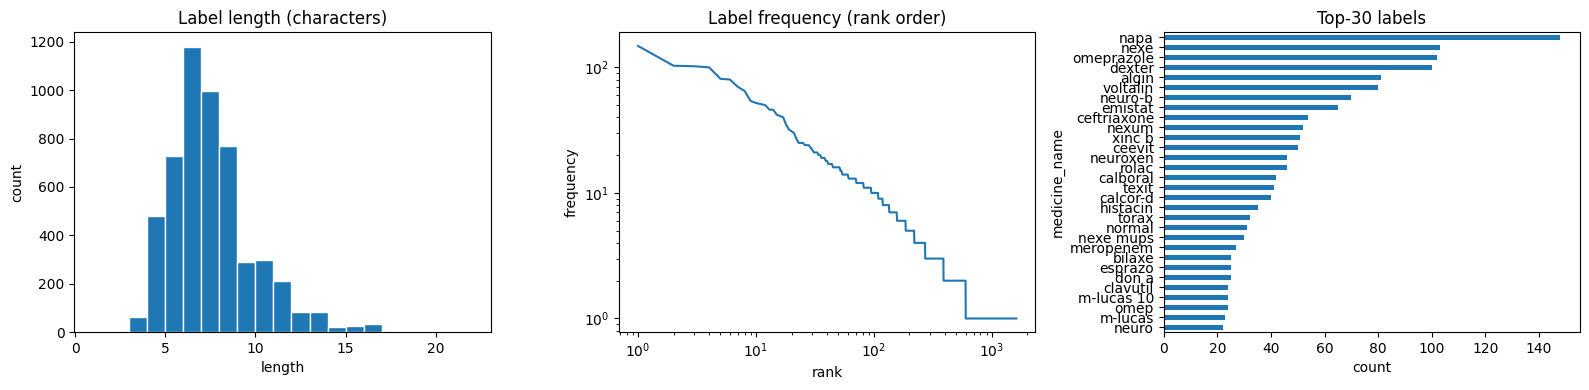

labels occurring exactly once: 1014 (62.9% of unique labels)


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

lengths = clean.medicine_name.str.len()
axes[0].hist(lengths, bins=range(1, lengths.max() + 2), edgecolor="white")
axes[0].set(title="Label length (characters)", xlabel="length", ylabel="count")

freq = clean.medicine_name.value_counts()
axes[1].plot(range(1, len(freq) + 1), freq.values)
axes[1].set(title="Label frequency (rank order)", xlabel="rank", ylabel="frequency",
            yscale="log", xscale="log")

freq.head(30).plot.barh(ax=axes[2])
axes[2].invert_yaxis(); axes[2].set(title="Top-30 labels", xlabel="count")

plt.tight_layout()
plt.savefig(FIG_DIR / "custom_dataset_eda.png", dpi=200)
plt.show()

singletons = int((freq == 1).sum())
print(f"labels occurring exactly once: {singletons} "
      f"({singletons / clean.medicine_name.nunique():.1%} of unique labels)")

## 4. Reproducible 70/15/15 split + seen/unseen-vocabulary flag

Split is at the *image* level with a fixed seed. Because the label distribution is
heavily long-tailed (many singletons), some test labels never occur in training —
rather than fighting this, we **flag** it: each val/test row gets `seen_in_train`,
enabling separate reporting of recognition on in-vocabulary vs out-of-vocabulary
medicine names (a key analysis for the evaluation chapter).

**Limitation to state in the thesis:** writer identity is unavailable, so the split is
random rather than writer-disjoint; reported results therefore measure generalisation
to unseen *images*, not provably unseen *handwriting styles*.

In [5]:
idx = rng.permutation(len(clean))
n_train = int(0.70 * len(clean))
n_val = int(0.15 * len(clean))

splits = {
    "train": clean.iloc[idx[:n_train]].reset_index(drop=True),
    "val":   clean.iloc[idx[n_train:n_train + n_val]].reset_index(drop=True),
    "test":  clean.iloc[idx[n_train + n_val:]].reset_index(drop=True),
}

train_vocab = set(splits["train"].medicine_name)
for name in ("val", "test"):
    splits[name]["seen_in_train"] = splits[name].medicine_name.isin(train_vocab)

for name, part in splits.items():
    part.to_csv(OUT_DIR / f"{name}.csv", index=False)
    seen = f" | seen-in-train: {part.seen_in_train.mean():.1%}" if name != "train" else ""
    print(f"{name:5s}: {len(part):5d} rows, {part.medicine_name.nunique():4d} unique labels{seen}")

train:  3693 rows, 1287 unique labels
val  :   791 rows,  442 unique labels | seen-in-train: 78.6%
test :   792 rows,  458 unique labels | seen-in-train: 77.4%


## 5. Visual sanity check — 12 random (image, label) pairs
Confirm with your own eyes that labels match images. If any pair looks wrong here,
audit more rows before training: label noise caps achievable accuracy.

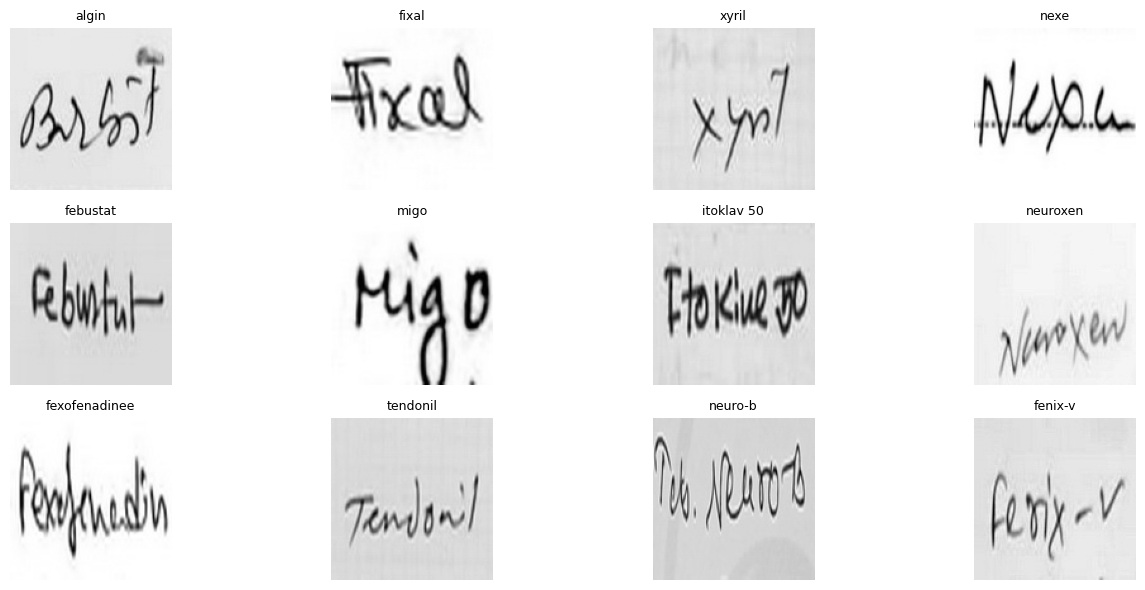

In [6]:
sample = splits["train"].sample(12, random_state=SEED)
fig, axes = plt.subplots(3, 4, figsize=(14, 6))
from PIL import Image
for ax, (_, r) in zip(axes.flat, sample.iterrows()):
    try:
        ax.imshow(Image.open(IMG_DIR / r.image_filename).convert("L"), cmap="gray")
        ax.set_title(r.medicine_name, fontsize=9)
    except FileNotFoundError:
        ax.set_title(f"MISSING: {r.image_filename}", fontsize=8, color="red")
    ax.axis("off")
plt.tight_layout(); plt.show()

## 6. Thesis checklist from this notebook
1. Report raw audit numbers (non-ASCII contamination, case duplicates) — annotation
   noise in real prescription data is a *finding*; cite the cleaning log as evidence.
2. Justify each cleaning switch (`LOWERCASE`, `FILTER_NON_MEDICINE`, the token list).
3. Include the EDA figure and the singleton percentage — this motivates the
   seen/unseen-vocabulary evaluation.
4. State the random-split limitation (no writer IDs) honestly.
**Image-dimension note (from dataset diagnostic):** source crops are 128x128 with some
wider images (up to ~1342 px) for long multi-word names. When training on this data,
raise Notebook 01's `Config.max_width` from 160 to ~320 so long names
(e.g. 'genimet sr 500g') are not truncated by the width cap. Height-32 resize is fine.

5. To train the baseline on this data, point Notebook 01's `Config` at
   `splits/{train,val,test}.csv` with `img_col="image_filename"`,
   `label_col="medicine_name"`, and the images directory for all three splits.